In [2]:
import os, random, glob, time
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict

import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

!pip -q install segmentation-models-pytorch==0.3.3

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.4 MB/s eta 0:00:0000:01


In [3]:
# ============================================================
# 1) Repro + device
# ============================================================

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [6]:
# ============================================================
# 2) Configure paths
# ============================================================

KVASIR_IMAGES_DIR = "/kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG/images"
KVASIR_MASKS_DIR  = "/kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG/masks"

USE_EXTERNAL_TEST = True

EXTERNAL_DATASET = "CVC" 

# CVC-ClinicDB structure:
CVC_ROOT = "/kaggle/input/datasets/balraj98/cvcclinicdb/PNG"
CVC_IMAGES_DIR = os.path.join(CVC_ROOT, "Original")
CVC_MASKS_DIR  = os.path.join(CVC_ROOT, "Ground Truth")

In [7]:
# ============================================================
# 3) Helpers: list pairs, sanity checks
# ============================================================

def list_image_mask_pairs(images_dir: str, masks_dir: str, img_exts=(".jpg",".jpeg",".png")) -> List[Tuple[str,str]]:
    # Kvasir masks often have same filename but png.
    # We'll map by stem name.
    img_files = []
    for e in img_exts:
        img_files.extend(glob.glob(os.path.join(images_dir, f"*{e}")))
    img_files = sorted(img_files)

    mask_files = glob.glob(os.path.join(masks_dir, "*"))
    mask_files = sorted(mask_files)

    mask_map = {}
    for m in mask_files:
        stem = os.path.splitext(os.path.basename(m))[0]
        mask_map[stem] = m

    pairs = []
    for im in img_files:
        stem = os.path.splitext(os.path.basename(im))[0]
        if stem in mask_map:
            pairs.append((im, mask_map[stem]))
        else:
            # Sometimes masks have suffixes; attempt minimal fuzzy matching
            # (kept conservative; you can customize if needed)
            found = None
            for k in mask_map.keys():
                if k.startswith(stem) or stem.startswith(k):
                    found = mask_map[k]
                    break
            if found is not None:
                pairs.append((im, found))

    return pairs

def assert_dir_exists(path: str):
    if not os.path.isdir(path):
        raise FileNotFoundError(f"Directory not found: {path}")

assert_dir_exists(KVASIR_IMAGES_DIR)
assert_dir_exists(KVASIR_MASKS_DIR)

kvasir_pairs = list_image_mask_pairs(KVASIR_IMAGES_DIR, KVASIR_MASKS_DIR)
print("Kvasir pairs:", len(kvasir_pairs))
if len(kvasir_pairs) != 1000:
    print("WARNING: Kvasir-SEG is typically 1000 images. Your matched pair count differs.")

# External
external_pairs = []
if USE_EXTERNAL_TEST:
    if EXTERNAL_DATASET.upper() == "CVC":
        assert_dir_exists(CVC_IMAGES_DIR)
        assert_dir_exists(CVC_MASKS_DIR)
        external_pairs = list_image_mask_pairs(CVC_IMAGES_DIR, CVC_MASKS_DIR, img_exts=(".png",".jpg",".jpeg"))
        print("CVC pairs:", len(external_pairs))
    elif EXTERNAL_DATASET.upper() == "ETIS":
        assert_dir_exists(ETIS_IMAGES_DIR)
        assert_dir_exists(ETIS_MASKS_DIR)
        external_pairs = list_image_mask_pairs(ETIS_IMAGES_DIR, ETIS_MASKS_DIR, img_exts=(".png",".jpg",".jpeg"))
        print("ETIS pairs:", len(external_pairs))
    else:
        raise ValueError("EXTERNAL_DATASET must be 'CVC' or 'ETIS'.")

Kvasir pairs: 1000
CVC pairs: 612


In [8]:
# ============================================================
# 4) Protocol A split (900 train, 100 test) + internal val split
# ============================================================

def split_protocol_A(pairs: List[Tuple[str,str]], seed=SEED) -> Dict[str, List[Tuple[str,str]]]:
    assert len(pairs) >= 1000, "Expected at least 1000 pairs for Protocol A."
    idx = np.arange(len(pairs))
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    test_idx = idx[:100]
    trainval_idx = idx[100:1000]  # next 900

    trainval = [pairs[i] for i in trainval_idx]
    test = [pairs[i] for i in test_idx]

    # create val split from trainval: 800 train, 100 val
    rng2 = np.random.default_rng(seed + 1)
    tv_idx = np.arange(len(trainval))
    rng2.shuffle(tv_idx)
    val_idx = tv_idx[:100]
    train_idx = tv_idx[100:]

    train = [trainval[i] for i in train_idx]
    val = [trainval[i] for i in val_idx]

    return {"train": train, "val": val, "test": test}

splits = split_protocol_A(kvasir_pairs, seed=SEED)
print({k: len(v) for k, v in splits.items()})

{'train': 800, 'val': 100, 'test': 100}


In [9]:
# ============================================================
# 5) Dataset + Transforms
# ============================================================

IMG_SIZE = 352

train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    # Keeping VerticalFlip off by default for endoscopy realism:
    # A.VerticalFlip(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=15, border_mode=cv2.BORDER_CONSTANT, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

test_tfms = val_tfms

class PolypSegDataset(Dataset):
    def __init__(self, pairs: List[Tuple[str,str]], transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = cv2.imread(img_path)
        if img is None:
            raise RuntimeError(f"Failed to read image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise RuntimeError(f"Failed to read mask: {mask_path}")

        # binarize
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"]

        # mask shape should be [H,W] -> make [1,H,W]
        mask = mask.unsqueeze(0).float()
        return img, mask

train_ds = PolypSegDataset(splits["train"], transform=train_tfms)
val_ds   = PolypSegDataset(splits["val"], transform=val_tfms)
test_ds  = PolypSegDataset(splits["test"], transform=test_tfms)

BATCH_SIZE = 8
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

external_loader = None
if USE_EXTERNAL_TEST and len(external_pairs) > 0:
    ext_ds = PolypSegDataset(external_pairs, transform=test_tfms)
    external_loader = DataLoader(ext_ds, batch_size=1, shuffle=False,
                                 num_workers=NUM_WORKERS, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [10]:
# ============================================================
# 6) Model
# ============================================================

ENCODER = "timm-efficientnet-b0"
# ENCODER = "timm-efficientnet-b2"
# ENCODER = "timm-resnet34"
# ENCODER = "timm-mobilenetv3_large_100"

MODEL_NAME = "unetplusplus"  # "unet", "unetplusplus", "deeplabv3plus"

def build_model(model_name: str, encoder_name: str):
    if model_name.lower() == "unet":
        return smp.Unet(
            encoder_name=encoder_name,
            encoder_weights="imagenet",
            in_channels=3,
            classes=1,
            activation=None
        )
    if model_name.lower() == "unetplusplus":
        return smp.UnetPlusPlus(
            encoder_name=encoder_name,
            encoder_weights="imagenet",
            in_channels=3,
            classes=1,
            activation=None
        )
    if model_name.lower() == "deeplabv3plus":
        return smp.DeepLabV3Plus(
            encoder_name=encoder_name,
            encoder_weights="imagenet",
            in_channels=3,
            classes=1,
            activation=None
        )
    raise ValueError("Unknown model_name")

model = build_model(MODEL_NAME, ENCODER).to(device)
print(model.__class__.__name__, "with", ENCODER)

Downloading: "https://github.com/huggingface/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_b0-0af12548.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_b0-0af12548.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 45.2MB/s]


UnetPlusPlus with timm-efficientnet-b0


In [11]:
# ============================================================
# 7) Loss + Metrics
# ============================================================

bce = nn.BCEWithLogitsLoss()

# Dice loss (stable)
def dice_loss_from_logits(logits, targets, eps=1e-7):
    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    dice = (2.0 * inter + eps) / (union + eps)
    return 1.0 - dice.mean()

def combo_loss(logits, targets, w_bce=0.5, w_dice=0.5):
    return w_bce * bce(logits, targets) + w_dice * dice_loss_from_logits(logits, targets)

@torch.no_grad()
def dice_iou_from_logits(logits, targets, thr=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)
    dice = (2.0 * inter + eps) / (union + eps)

    iou = (inter + eps) / (preds.sum(dim=1) + targets.sum(dim=1) - inter + eps)
    return dice.mean().item(), iou.mean().item()

In [12]:
# ============================================================
# 8) Train / Validate loops (AMP + early stopping)
# ============================================================

LR = 3e-4
EPOCHS = 35
PATIENCE = 8

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

def run_one_epoch(model, loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    epoch_loss = 0.0
    epoch_dice = 0.0
    epoch_iou  = 0.0
    n = 0

    for imgs, masks in loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
                logits = model(imgs)
                loss = combo_loss(logits, masks, 0.5, 0.5)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        d, j = dice_iou_from_logits(logits.detach(), masks.detach())
        bs = imgs.size(0)
        epoch_loss += loss.item() * bs
        epoch_dice += d * bs
        epoch_iou  += j * bs
        n += bs

    return epoch_loss / n, epoch_dice / n, epoch_iou / n


best_val_dice = -1
best_path = "best_polyp_model.pt"
pat = 0

history = {"train_loss":[], "train_dice":[], "train_iou":[],
           "val_loss":[], "val_dice":[], "val_iou":[]}

for epoch in range(1, EPOCHS+1):
    t0 = time.time()

    tr_loss, tr_dice, tr_iou = run_one_epoch(model, train_loader, train=True)
    va_loss, va_dice, va_iou = run_one_epoch(model, val_loader, train=False)

    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_dice"].append(tr_dice)
    history["train_iou"].append(tr_iou)
    history["val_loss"].append(va_loss)
    history["val_dice"].append(va_dice)
    history["val_iou"].append(va_iou)

    improved = va_dice > best_val_dice
    if improved:
        best_val_dice = va_dice
        torch.save(model.state_dict(), best_path)
        pat = 0
    else:
        pat += 1

    dt = time.time() - t0
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train: loss {tr_loss:.4f}, dice {tr_dice:.4f}, iou {tr_iou:.4f} | "
          f"Val: loss {va_loss:.4f}, dice {va_dice:.4f}, iou {va_iou:.4f} | "
          f"{'BEST' if improved else '':4s} | time {dt:.1f}s")

    if pat >= PATIENCE:
        print("Early stopping triggered.")
        break

print("Best val dice:", best_val_dice)

/tmp/ipykernel_55/2579293898.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_55/2579293898.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Epoch 01/35 | Train: loss 0.4587, dice 0.6094, iou 0.4937 | Val: loss 0.2409, dice 0.8269, iou 0.7297 | BEST | time 103.4s
Epoch 02/35 | Train: loss 0.2579, dice 0.7851, iou 0.6875 | Val: loss 0.1519, dice 0.8771, iou 0.8031 | BEST | time 19.0s
Epoch 03/35 | Train: loss 0.1968, dice 0.8235, iou 0.7381 | Val: loss 0.1472, dice 0.8776, iou 0.8088 | BEST | time 19.3s
Epoch 04/35 | Train: loss 0.1680, dice 0.8471, iou 0.7638 | Val: loss 0.1321, dice 0.8834, iou 0.8183 | BEST | time 19.5s
Epoch 05/35 | Train: loss 0.1629, dice 0.8494, iou 0.7719 | Val: loss 0.1513, dice 0.8700, iou 0.8043 |      | time 19.7s
Epoch 06/35 | Train: loss 0.1329, dice 0.8734, iou 0.8018 | Val: loss 0.1417, dice 0.8774, iou 0.8130 |      | time 19.9s
Epoch 07/35 | Train: loss 0.1328, dice 0.8739, iou 0.8037 | Val: loss 0.1450, dice 0.8764, iou 0.8110 |      | time 19.7s
Epoch 08/35 | Train: loss 0.1281, dice 0.8751, iou 0.8085 | Val: loss 0.1260, dice 0.8834, iou 0.8217 | BEST | time 19.7s
Epoch 09/35 | Train: lo

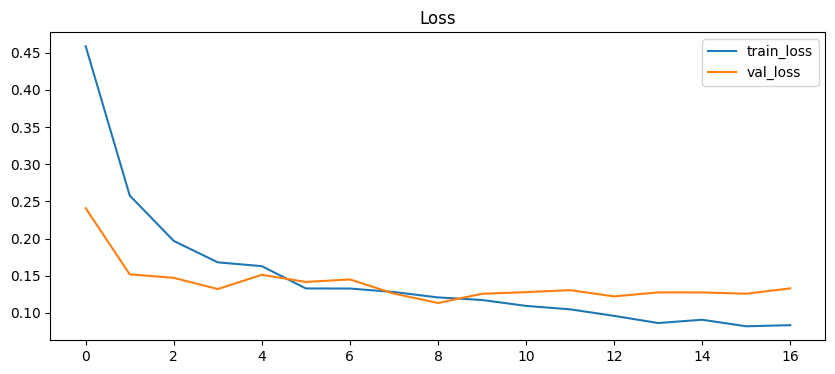

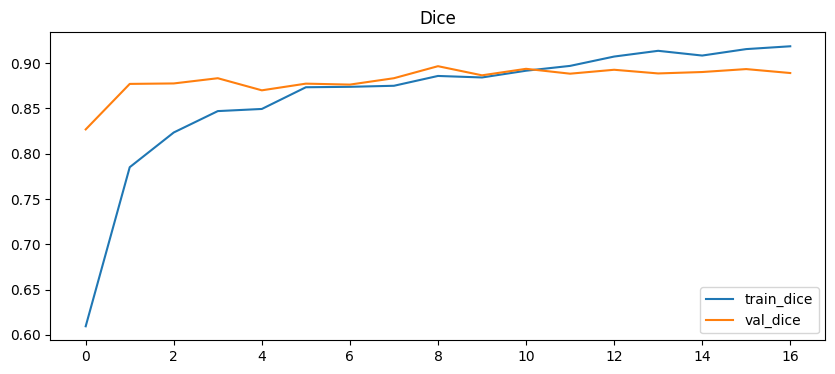

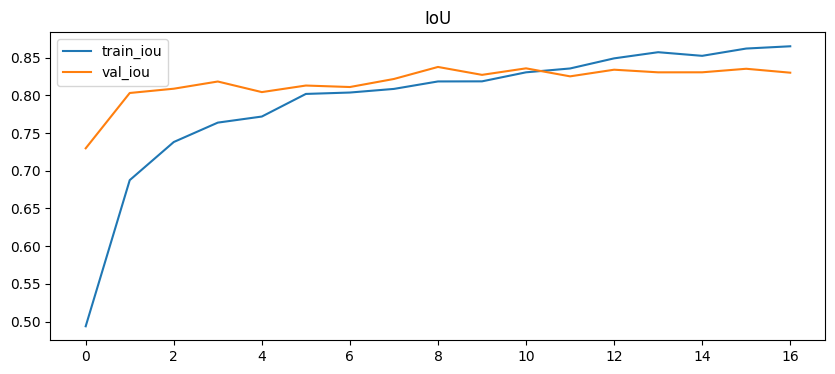

In [13]:
# ============================================================
# 9) Plot training curves
# ============================================================

def plot_history(hist):
    plt.figure(figsize=(10,4))
    plt.plot(hist["train_loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.legend(); plt.title("Loss"); plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(hist["train_dice"], label="train_dice")
    plt.plot(hist["val_dice"], label="val_dice")
    plt.legend(); plt.title("Dice"); plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(hist["train_iou"], label="train_iou")
    plt.plot(hist["val_iou"], label="val_iou")
    plt.legend(); plt.title("IoU"); plt.show()

plot_history(history)

In [14]:
# ============================================================
# 10) Evaluation: Kvasir test (100) + external dataset
# ============================================================

model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

@torch.no_grad()
def evaluate_loader(model, loader, name="Test"):
    losses = []
    dices = []
    ious  = []
    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        loss = combo_loss(logits, masks, 0.5, 0.5).item()
        d, j = dice_iou_from_logits(logits, masks)

        losses.append(loss)
        dices.append(d)
        ious.append(j)

    print(f"{name} -> Loss: {np.mean(losses):.4f} | Dice: {np.mean(dices):.4f} | IoU: {np.mean(ious):.4f}")
    return float(np.mean(losses)), float(np.mean(dices)), float(np.mean(ious))

k_loss, k_dice, k_iou = evaluate_loader(model, test_loader, name="Kvasir (Protocol A test=100)")

if USE_EXTERNAL_TEST and external_loader is not None:
    ext_name = "CVC-ClinicDB" if EXTERNAL_DATASET.upper()=="CVC" else "ETIS"
    e_loss, e_dice, e_iou = evaluate_loader(model, external_loader, name=f"External ({ext_name})")

Kvasir (Protocol A test=100) -> Loss: 0.1625 | Dice: 0.8575 | IoU: 0.7847
External (CVC-ClinicDB) -> Loss: 0.1511 | Dice: 0.8259 | IoU: 0.7434


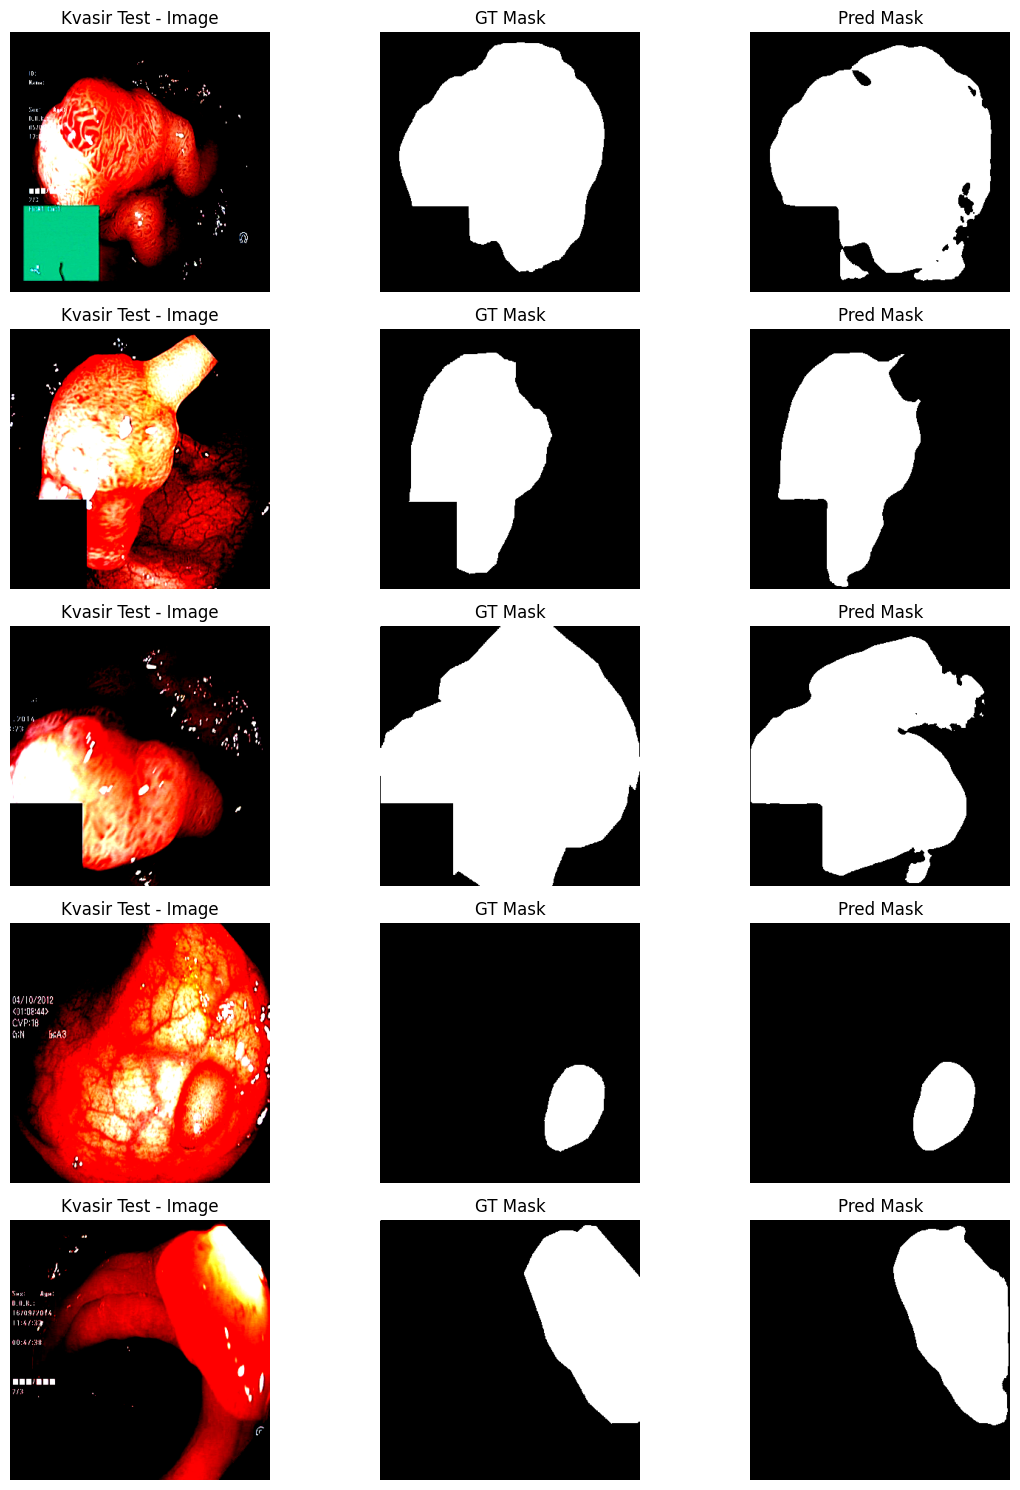

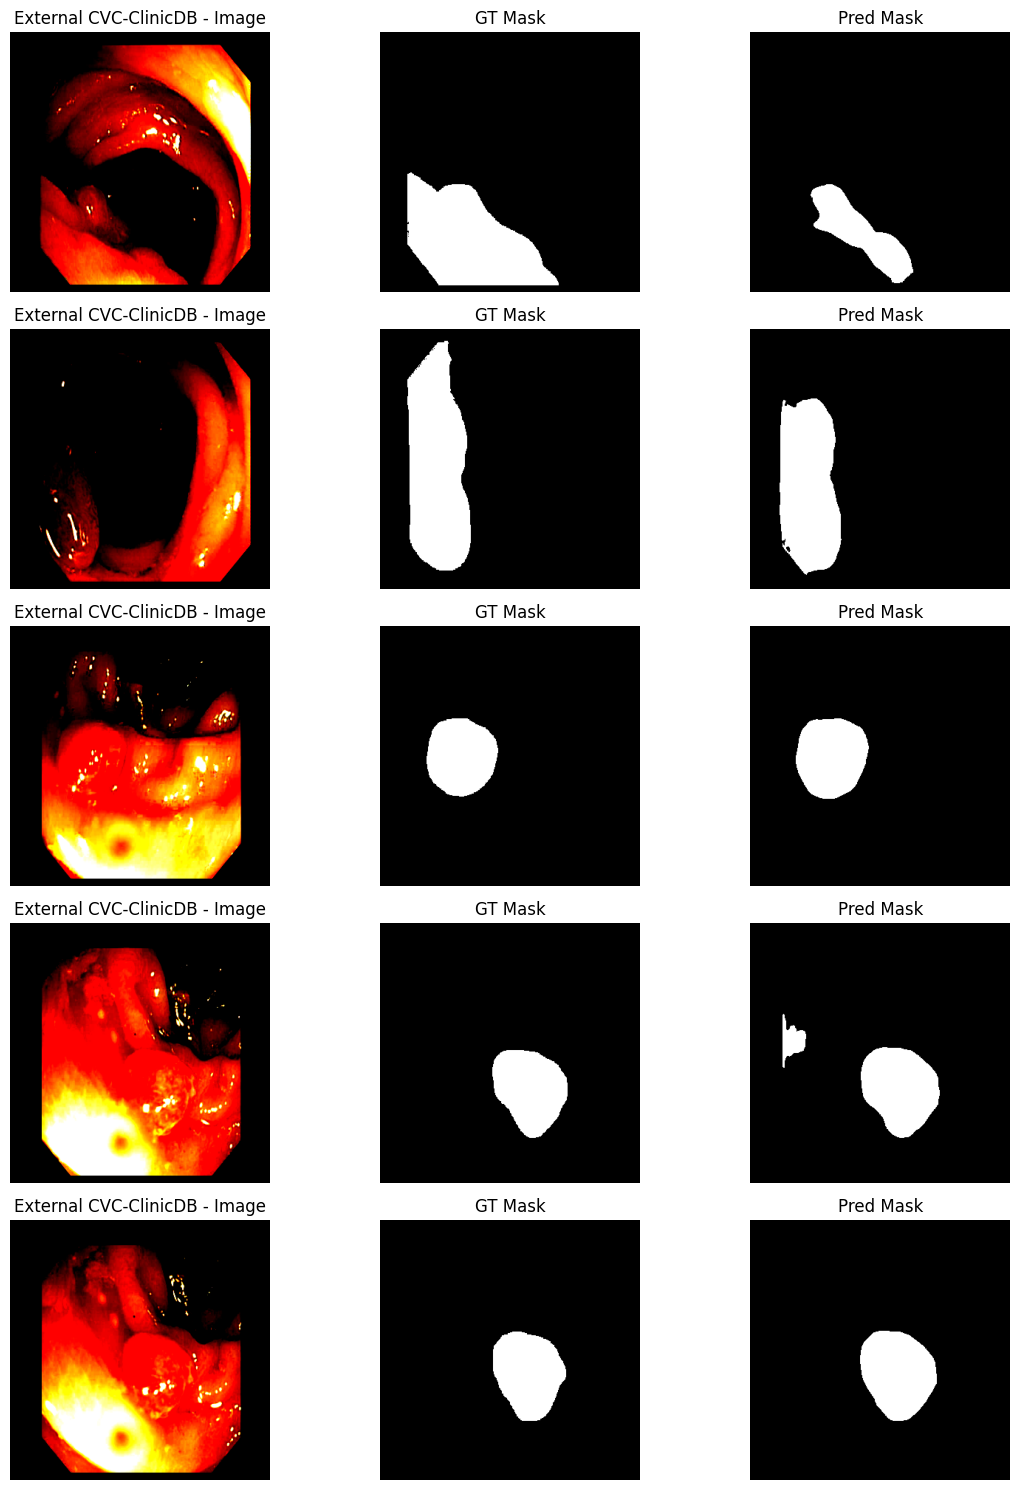

In [15]:
# ============================================================
# 11) Visualize predictions (Kvasir + External)
# ============================================================

def denorm(img_tensor):
    # Albumentations Normalize() uses mean=(0,0,0), std=(1,1,1) by default unless set,
    # so we can just clamp and convert. (If you set ImageNet mean/std, adjust here.)
    img = img_tensor.detach().cpu().permute(1,2,0).numpy()
    img = np.clip(img, 0, 1)
    return img

@torch.no_grad()
def show_samples(loader, n=5, title="Samples"):
    model.eval()
    shown = 0
    plt.figure(figsize=(12, 3*n))
    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits)
        pred = (probs > 0.5).float()

        img_np = denorm(imgs[0])
        gt_np = masks[0,0].detach().cpu().numpy()
        pr_np = pred[0,0].detach().cpu().numpy()

        r = shown*3
        plt.subplot(n, 3, r+1); plt.imshow(img_np); plt.title(f"{title} - Image"); plt.axis("off")
        plt.subplot(n, 3, r+2); plt.imshow(gt_np, cmap="gray"); plt.title("GT Mask"); plt.axis("off")
        plt.subplot(n, 3, r+3); plt.imshow(pr_np, cmap="gray"); plt.title("Pred Mask"); plt.axis("off")

        shown += 1
        if shown >= n:
            break
    plt.tight_layout()
    plt.show()

show_samples(test_loader, n=5, title="Kvasir Test")

if USE_EXTERNAL_TEST and external_loader is not None:
    ext_name = "CVC-ClinicDB" if EXTERNAL_DATASET.upper()=="CVC" else "ETIS"
    show_samples(external_loader, n=5, title=f"External {ext_name}")

In [16]:
# ============================================================
# 12) Summary cell
# ============================================================

print("\n========== SUMMARY ==========")
print(f"Protocol: A (900 train / 100 test) with internal val=100 from train")
print(f"Model: {MODEL_NAME} | Encoder: {ENCODER} | IMG_SIZE: {IMG_SIZE}")
print(f"Kvasir Test Dice: {k_dice:.4f} | IoU: {k_iou:.4f}")
if USE_EXTERNAL_TEST and external_loader is not None:
    print(f"External ({ext_name}) Dice: {e_dice:.4f} | IoU: {e_iou:.4f}")
print("=============================\n")


========== SUMMARY ==========
Protocol: A (900 train / 100 test) with internal val=100 from train
Model: unetplusplus | Encoder: timm-efficientnet-b0 | IMG_SIZE: 352
Kvasir Test Dice: 0.8575 | IoU: 0.7847
External (CVC-ClinicDB) Dice: 0.8259 | IoU: 0.7434

